In [63]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict, Literal, Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
import operator

In [64]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview"
)

In [65]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation of given tweet")
    feedback: str = Field(description="Feeback for the given tweet")

In [66]:
evaluator_model = llm.with_structured_output(TweetEvaluation)

In [67]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: list[str]
    feedback_history: list[str]

In [ ]:
def generate_tweet(state: TweetState):
    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
    Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

    Rules:
    - Do NOT use question-answer format.
    - Max 280 characters.
    - Use observational humor, irony, sarcasm, or cultural references.
    - Think in meme logic, punchlines, or relatable takes.
    - Use simple, day to day english
    """)
    ]

    response = llm.invoke(messages).content

    iteration = state['iteration'] + 1 

    return {'tweet': response, 'tweet_history': [response], 'iteration': iteration}
    

In [ ]:
def evaluate_tweet(state: TweetState):
    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
    Evaluate the following tweet:

    Tweet: "{state['tweet']}"

    Use the criteria below to evaluate the tweet:

    1. Originality – Is this fresh, or have you seen it a hundred times before?  
    2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
    3. Punchiness – Is it short, sharp, and scroll-stopping?  
    4. Virality Potential – Would people retweet or share it?  
    5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

    Auto-reject if:
    - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
    - It exceeds 280 characters
    - It reads like a traditional setup-punchline joke
    - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

    ### Respond ONLY in structured format:
    - evaluation: "approved" or "needs_improvement"  
    - feedback: One paragraph explaining the strengths and weaknesses 
    """)
    ]

    response = evaluator_model.invoke(messages)

    return {'evaluation': response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [70]:
def optimise_tweet(state: TweetState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
    Improve the tweet based on this feedback:
    "{state['feedback']}"

    Topic: "{state['topic']}"
    Original Tweet:
    {state['tweet']}

    Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
    """)
    ]

    response = llm.invoke(messages).content

    iteration = state['iteration'] + 1

    return {'tweet': response, 'tweet_history': [response], 'iteration': iteration}

In [71]:
def route_evaluation(state: TweetState):
    if state['evaluation']=="approved" or state['iteration'] >= state['max_iteration']:
        return "approved"
    else:
        return "needs_improvement"

In [72]:
graph = StateGraph(TweetState)

graph.add_node('evaluator', evaluate_tweet)
graph.add_node('generator', generate_tweet)
graph.add_node('optimiser', optimise_tweet)

graph.add_edge(START, 'generator')
graph.add_edge('generator', 'evaluator')
graph.add_conditional_edges('evaluator', route_evaluation, {"approved": END, "needs_improvement": 'optimiser'})
graph.add_edge('optimiser', 'evaluator')

workflow = graph.compile()

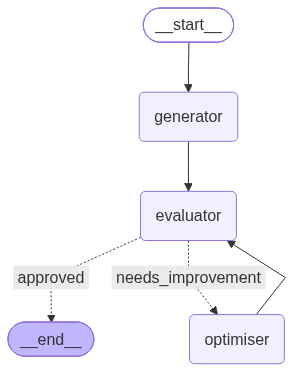

In [73]:
workflow

In [74]:
input_state = {
    'topic': "fasdfa",
    'iteration': 0,
    'max_iteration': 5
}

In [75]:
result = workflow.invoke(input_state)

ChatGoogleGenerativeAIError: Error calling model 'gemini-3-flash-preview' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash\nPlease retry in 37.956681208s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-F

In [ ]:
for idx, tweet in enumerate(result['tweet_history']):
    print(f"{idx} - {tweet[0]['text']}\n")

0 - “fasdfa” isn’t a typo. It’s a spiritual scream. It’s the sound of your last brain cell resigning in real-time. 

We spent years learning grammar just to realize that hitting the middle row in a blind panic captures the modern human experience better than any poem ever could.

